<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-3-CDC-BRFSS-processing/notebooks/brfss_eda_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

### Step 2 - Clone Repository & Load Dataset
We first clone the repository into the notebook environment, move into the project folder, and then load the CDC BRFSS CSV into a pandas DataFrame.

A try/except block is used so that any path issue is caught immediately. The first 10 rows are displayed for a quick visual check.


In [12]:
!git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

os.chdir("Predicting-Type-2-Diabetes")

path = "data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
try:
    df = pd.read_csv(path)
    print("CDC BRFSS dataset loaded successfully")
except Exception as e:
    print(f"Failed to load dataset: {e}")

df.head(10)

Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 146 (delta 12), reused 0 (delta 0), pack-reused 128 (from 1)
Receiving objects: 100% (146/146), 3.37 MiB | 6.22 MiB/s, done.
Resolving deltas: 100% (61/61), done.
CDC BRFSS dataset loaded successfully


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


The CDC BRFSS dataset is much larger than the other datasets in the project and contains only numeric columns. Most features are binary indicators, while others such as `BMI`, `MentHlth`, `PhysHlth`, `Age`, `Education`, and `Income` are continuous or ordinal-like variables.

The target column is `Diabetes_binary`, which is already encoded as a binary class label.

### Step 3 - Shape & Data Types
Before further analysis, we confirm the dataset dimensions and inspect the data type of each column. This tells us whether additional encoding is needed before modelling.


In [13]:
print("-" * 30)
print(" Shape & Data Types")
print("-" * 30)
print(f"\n  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)

------------------------------
 Shape & Data Types
------------------------------

  Rows    : 253,680
  Columns : 22

Data Types:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


### Step 4 - Feature Overview, Null Values, and Duplicate Check
We examine the numerical summary statistics, check for null values, and inspect duplicate rows.

Because all columns are numeric in this dataset, no categorical text encoding is required.


In [14]:
print("-" * 50)
print(" Numerical Columns, Null Values & Duplicates")
print("-" * 50)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nSummary Statistics:")
display(df[numerical_cols].describe().round(2))

print("\nNull Values:")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

--------------------------------------------------
 Numerical Columns, Null Values & Duplicates
--------------------------------------------------

Numerical Columns:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Summary Statistics:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.14,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,0.81,0.06,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.35,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,0.39,0.23,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,1.00,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00



Null Values:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total nulls: 0

Duplicate rows: 24,206


### Step 5 - Class Distribution
We examine the distribution of the target variable `Diabetes_binary` to determine whether the dataset is balanced.

This step is especially important in medical classification because a model can appear to perform well by mostly predicting the majority class, while missing many actual diabetic cases.

In [15]:
print("-" * 31)
print(" Class Distribution")
print("-" * 31)

class_counts = df["Diabetes_binary"].value_counts().sort_index()
class_pct = df["Diabetes_binary"].value_counts(normalize=True).sort_index() * 100

print(pd.DataFrame({
    "Count": class_counts.astype(int),
    "Percentage (%)": class_pct.round(2)
}))

-------------------------------
 Class Distribution
-------------------------------
                  Count  Percentage (%)
Diabetes_binary                        
0.0              218334           86.07
1.0               35346           13.93


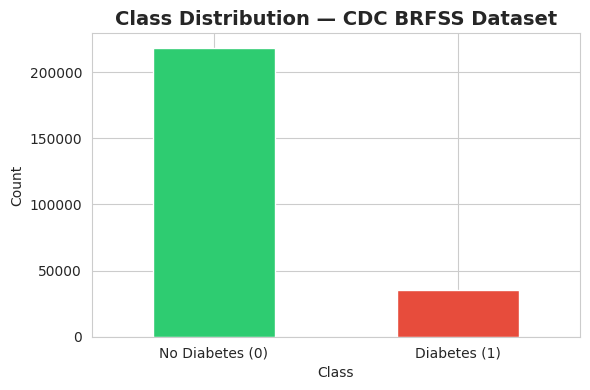

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
df["Diabetes_binary"].value_counts().sort_index().plot(kind="bar", color=["#2ECC71", "#E74C3C"], ax=ax)

ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_title("Class Distribution — CDC BRFSS Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("class_distribution_cdc_brfss.png", dpi=150)
plt.show()

**Imbalance Severity Note:**  
The CDC BRFSS dataset is **severely imbalanced**. The majority class (`No Diabetes = 0`) makes up about **86%** of the dataset, while the minority class (`Diabetes = 1`) makes up about **14%**, giving a class ratio of roughly **6.18:1**.  

This means that **accuracy alone can be misleading**, since a model could predict the majority class most of the time and still appear to perform well. Because of this, the project uses:
- **stratified train/test splitting**
- **SMOTE on the training set only**
- evaluation metrics such as **precision, recall, F1-score, and AUC-ROC**

In [17]:
class_counts = df["Diabetes_binary"].value_counts().sort_index()
no_diabetes = class_counts[0]
diabetes = class_counts[1]

no_diabetes_pct = (no_diabetes / len(df)) * 100
diabetes_pct = (diabetes / len(df)) * 100
imbalance_ratio = no_diabetes / diabetes

print("Imbalance Severity Note")
print(f"No Diabetes (0): {no_diabetes:,} ({no_diabetes_pct:.2f}%)")
print(f"Diabetes (1): {diabetes:,} ({diabetes_pct:.2f}%)")
print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")

Imbalance Severity Note
No Diabetes (0): 218,334 (86.07%)
Diabetes (1): 35,346 (13.93%)
Majority-to-minority ratio: 6.18:1
